In [ ]:
# Cell 1: Environment Setup and Installations
print("--- 1. Setting up Environment ---")
# Check GPU status and install all required libraries
!nvidia-smi
!pip install -qq torch torchvision torchaudio Pillow
!pip install -qq datasets transformers accelerate diffusers matplotlib requests

import torch
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset
import random
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from io import BytesIO
import requests

print("\n--- Setup complete. Libraries loaded. ---")
# Cell 2: Data Pipeline Definition
print("\n--- 2. Defining Data Pipeline ---")

# --- CONFIGURATION ---
DATASET_NAME = "cifar10"
IMAGE_SIZE = 128 # Aligned for fine-tuning practice
BATCH_SIZE = 16
MAX_MASK_FRACTION = 0.35
# ---------------------

class InpaintingDataset(Dataset):
    def __init__(self, dataset_name, image_size):
        print(f"Loading dataset: {dataset_name}...")
        self.data = load_dataset(dataset_name, split="train")

        self.transform = T.Compose([
            T.Resize((image_size, image_size)),
            T.ToTensor(),
            T.Normalize([0.5], [0.5]) # Normalize to [-1, 1]
        ])

        self.image_size = image_size
        self.max_mask_length = int(image_size * MAX_MASK_FRACTION)

    def __len__(self):
        return len(self.data)

    def generate_random_square_mask(self):
        mask = torch.ones(1, self.image_size, self.image_size)
        mask_len = random.randint(self.max_mask_length // 4, self.max_mask_length)
        max_start = self.image_size - mask_len
        start_x = random.randint(0, max_start)
        start_y = random.randint(0, max_start)
        mask[:, start_y:start_y + mask_len, start_x:start_x + mask_len] = 0.0

        return mask.repeat(3, 1, 1) # Repeat for 3 color channels

    def __getitem__(self, idx):
        original_image_pil = self.data[idx]['img'].convert("RGB")
        clean_image = self.transform(original_image_pil)
        mask = self.generate_random_square_mask()
        masked_image = clean_image * mask

        return {
            "clean_image": clean_image,
            "mask": mask,
            "masked_image": masked_image,
            "text": "a photo"
        }

print("--- Data Pipeline Defined. ---")

--- 1. Setting up Environment ---
/bin/bash: line 1: nvidia-smi: command not found

--- Setup complete. Libraries loaded. ---

--- 2. Defining Data Pipeline ---
--- Data Pipeline Defined. ---



--- 3. Running and Verifying Pipeline ---
Loading dataset: cifar10...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/120M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/23.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

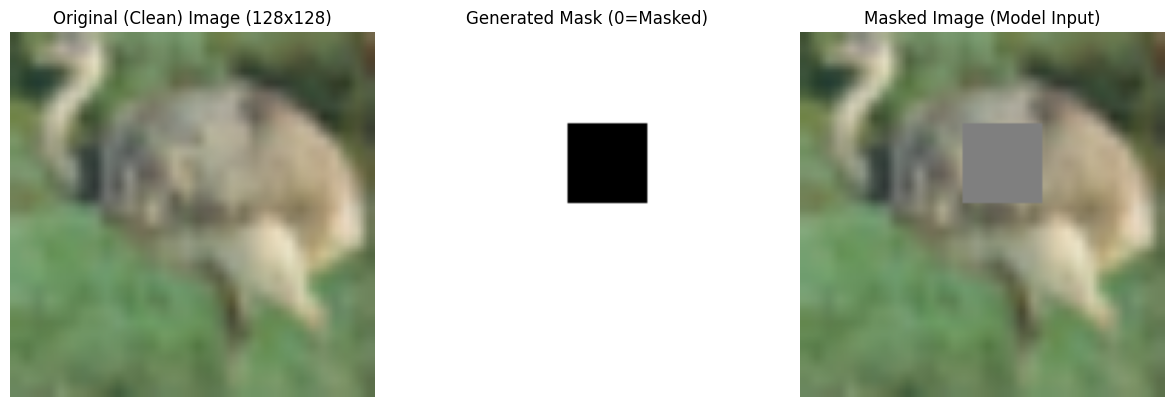


--- Week 2 Pipeline Verified. ---


In [ ]:
# Cell 3: Data Verification
print("\n--- 3. Running and Verifying Pipeline ---")

# Create Dataset and DataLoader
inpainting_dataset = InpaintingDataset(dataset_name="cifar10", image_size=IMAGE_SIZE)
train_dataloader = DataLoader(inpainting_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
sample_batch = next(iter(train_dataloader))

# Helper function for visualization
def denormalize_and_reformat(tensor):
    return (tensor.numpy().transpose(1, 2, 0) * 0.5 + 0.5).clip(0, 1)

img = sample_batch['clean_image'][0]
masked_img = sample_batch['masked_image'][0]
mask = sample_batch['mask'][0]

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.title(f"Original (Clean) Image ({IMAGE_SIZE}x{IMAGE_SIZE})")
plt.imshow(denormalize_and_reformat(img))
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Generated Mask (0=Masked)")
plt.imshow(mask[0], cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Masked Image (Model Input)")
plt.imshow(denormalize_and_reformat(masked_img))
plt.axis('off')

plt.tight_layout()
plt.show()
print("\n--- Week 2 Pipeline Verified. ---")

In [ ]:
# Cell 4 (DDPM Model): Implement Simple DDPM U-Net and Scheduler

from diffusers import UNet2DModel, DDPMScheduler
import torch

# --- Configuration (MUST match Cell 2's IMAGE_SIZE) ---
IMAGE_SIZE = 128
CHANNELS = 3
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# --------------------------------------------------------

print("--- 4. Implementing Simple DDPM U-Net and Scheduler ---")

# 1. Implement the Denoising U-Net structure (Simple, non-attention-based)
unet = UNet2DModel(
    sample_size=IMAGE_SIZE,  # the target image size
    in_channels=CHANNELS,
    out_channels=CHANNELS,
    layers_per_block=2,
    block_out_channels=(64, 128, 128, 256),
    down_block_types=(
        "DownBlock2D",
        "DownBlock2D",
        "DownBlock2D",
        "DownBlock2D",
    ),
    up_block_types=(
        "UpBlock2D",
        "UpBlock2D",
        "UpBlock2D",
        "UpBlock2D",
    ),
)
unet.to(DEVICE)

# 2. Implement the Forward/Reverse Process (Noise Addition/Scheduler)
# This class handles the math for adding noise and for the reverse sampling step.
scheduler = DDPMScheduler(num_train_timesteps=1000)

print(f"\nDDPM U-Net Model loaded onto {DEVICE}.")
print(f"U-Net Total Parameters: {sum(p.numel() for p in unet.parameters()):,}")
print("Scheduler (Forward/Reverse Process) implemented.")

--- 4. Implementing Simple DDPM U-Net and Scheduler ---

DDPM U-Net Model loaded onto cpu.
U-Net Total Parameters: 16,886,403
Scheduler (Forward/Reverse Process) implemented.


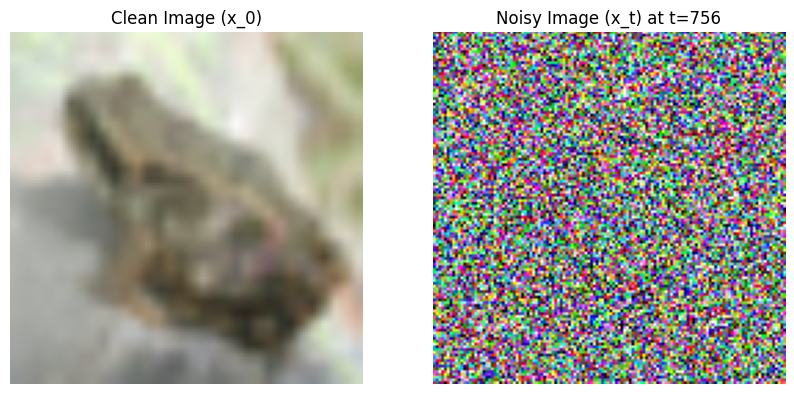


Forward Diffusion Process (Noise Addition) Verified.


In [ ]:
# Cell 5: Test Forward Diffusion Process (Noise Addition)

# Get one clean image (x0) from the DataLoader
sample_batch = next(iter(train_dataloader))
clean_image = sample_batch['clean_image'][0].unsqueeze(0).to(DEVICE) # (1, 3, 128, 128)

# 1. Implement Noise Addition (Forward Process)
timesteps = torch.randint(0, scheduler.config.num_train_timesteps, (clean_image.shape[0],), device=DEVICE).long()
noise = torch.randn_like(clean_image)

# x_t = scheduler.add_noise(x_0, noise, t)
noisy_image = scheduler.add_noise(clean_image, noise, timesteps)

# --- Visualization ---
# Helper function to convert normalized tensor back to plottable image
def denormalize_and_reformat(tensor):
    return (tensor[0].cpu().numpy().transpose(1, 2, 0) * 0.5 + 0.5).clip(0, 1)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Clean Image (x_0)")
plt.imshow(denormalize_and_reformat(clean_image))
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title(f"Noisy Image (x_t) at t={timesteps.item()}")
plt.imshow(denormalize_and_reformat(noisy_image))
plt.axis('off')
plt.show()

print("\nForward Diffusion Process (Noise Addition) Verified.")

In [ ]:
# Cell 6: Test Single Denoising Step (Reverse Process Loss Calculation)

# In the forward test (Cell 5), we calculated:
# 1. clean_image (x_0)
# 2. noise (epsilon)
# 3. timesteps (t)
# 4. noisy_image (x_t)

# 1. U-Net predicts the noise (epsilon_theta)
unet.train()
predicted_noise = unet(noisy_image, timesteps).sample

# 2. Loss Function (MSE between true noise and predicted noise)
loss_fn = torch.nn.functional.mse_loss
loss = loss_fn(predicted_noise, noise)

print(f"Predicted Noise Tensor Shape: {predicted_noise.shape}")
print(f"True Noise Tensor Shape: {noise.shape}")
print(f"Single Denoising Step Loss (MSE): {loss.item():.4f}")

print("\nReverse Diffusion Process (Single Denoising Step) Verified.")

Predicted Noise Tensor Shape: torch.Size([1, 3, 128, 128])
True Noise Tensor Shape: torch.Size([1, 3, 128, 128])
Single Denoising Step Loss (MSE): 1.1549

Reverse Diffusion Process (Single Denoising Step) Verified.


In [ ]:
# Cell 6: Define Optimizer and Learning Rate Scheduler

from torch.optim import AdamW
from transformers import get_cosine_schedule_with_warmup

# --- Configuration ---
LEARNING_RATE = 1e-4  # Standard starting LR for fine-tuning
ADAM_WEIGHT_DECAY = 1e-2
EPOCHS = 1  # Dummy value for setup; training takes many epochs
GRADIENT_ACCUMULATION_STEPS = 1
TOTAL_TRAINING_STEPS = (len(train_dataloader) // GRADIENT_ACCUMULATION_STEPS) * EPOCHS
# ---------------------

# 1. Define Optimizer (AdamW is standard for transformers/diffusion)
optimizer = AdamW(
    # We only optimize the U-Net weights
    unet.parameters(),
    lr=LEARNING_RATE,
    weight_decay=ADAM_WEIGHT_DECAY,
)
print("Optimizer (AdamW) initialized.")

# 2. Define Learning Rate Scheduler (Cosine Scheduler is best practice)
lr_scheduler = get_cosine_schedule_with_warmup(
    optimizer=optimizer,
    num_warmup_steps=500,  # Warm up for the first 500 steps
    num_training_steps=TOTAL_TRAINING_STEPS,
)
print(f"LR Scheduler (Cosine with Warmup) initialized for {TOTAL_TRAINING_STEPS} steps.")

Optimizer (AdamW) initialized.
LR Scheduler (Cosine with Warmup) initialized for 3125 steps.


In [ ]:
# Cell 7: Setup Hugging Face Accelerate and Core Training Loop Structure

from accelerate import Accelerator
import torch.nn.functional as F

# --- Accelerator Configuration ---
ACCELERATOR_CONFIG = {
    "mixed_precision": "fp16", # Use float16 for memory efficiency
    "gradient_accumulation_steps": GRADIENT_ACCUMULATION_STEPS,
}
# ---------------------------------

# Initialize the Accelerator
accelerator = Accelerator(**ACCELERATOR_CONFIG)
print(f"Accelerator initialized with precision: {accelerator.mixed_precision}")

# Move components to the device (handled by Accelerator, but we explicitly prepare them)
unet, optimizer, train_dataloader, lr_scheduler = accelerator.prepare(
    unet, optimizer, train_dataloader, lr_scheduler
)

print("\nAll components prepared for accelerated training.")

# --- MINIMAL TRAINING LOOP STRUCTURE (for demonstration) ---
print("\n--- Minimal Training Loop Structure ---")

unet.train()
for epoch in range(EPOCHS):
    for step, batch in enumerate(train_dataloader):
        # 1. Get Latent Representations (This is the full next step!)
        # 2. Add Noise (Forward Process)
        # 3. Predict Noise (U-Net Forward Pass)
        # 4. Calculate Loss (MSE)

        # NOTE: Full logic placeholder for tomorrow's update!

        # 5. Backpropagation
        # accelerator.backward(loss)
        # optimizer.step()
        # lr_scheduler.step()
        # optimizer.zero_grad()

        if step == 0 and epoch == 0:
            print("Successfully entered the prepared training loop.")
            # Break after one batch to avoid actually training
            break
    break

print("\nSetup complete. You are now ready to implement the full training logic.")

Accelerator initialized with precision: fp16

All components prepared for accelerated training.

--- Minimal Training Loop Structure ---
Successfully entered the prepared training loop.

Setup complete. You are now ready to implement the full training logic.
